In [43]:
# LabOne Q:
from laboneq.simple import *

import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from pathlib import Path
import time
import os
import laboneq
from datetime import datetime
from laboneq.contrib.example_helpers.plotting.plot_helpers import (
    plot_results,
    plot_simulation,
)
from laboneq.analysis.fitting import oscillatory

print(laboneq.__version__)

2.51.0


In [44]:
"""Descriptor for a QCCS consisting of a single SHFQC
"""
descriptor_shfqc = """ 
instruments:
  SHFQC:
  - address: DEV12296
    uid: device_shfqc

connections:
  device_shfqc:
    - iq_signal: q0/drive_line
      ports: SGCHANNELS/1/OUTPUT
    - iq_signal: q0/measure_line
      ports: [QACHANNELS/0/OUTPUT]
    - acquire_signal: q0/acquire_line
      ports: [QACHANNELS/0/INPUT]
"""
# Define and Load our Device Setup
device_setup = DeviceSetup.from_descriptor(
    descriptor_shfqc,
    server_host="127.0.0.1",  # ip address of the LabOne dataserver used to communicate with the instruments
    server_port="8004",  # port number of the dataserver - default is 8004
    setup_name="UCLA_SHFQC",  # setup name
)
# Are we emulating? or actually creating pulses?
emulate = False
# create and connect to session
session = Session(device_setup=device_setup)
session.connect(do_emulation=emulate)

[2025.08.24 19:17:27.534] INFO    Logging initialized from [Default inline config in laboneq.laboneq_logging] logdir is c:\Users\qubit\Desktop\Yi\Measurement\laboneq_output\log
[2025.08.24 19:17:27.537] INFO    VERSION: laboneq 2.51.0
[2025.08.24 19:17:27.538] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.24 19:17:27.543] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.24 19:17:27.549] WARNING SHFQC/QA:dev12296: Include the device options 'SHFQC/QC4CH' in the device setup ('options' field of the 'instruments' list in the device setup descriptor, 'device_options' argument when constructing instrument objects to be added to 'DeviceSetup' instances). This will become a strict requirement in the future.
[2025.08.24 19:17:27.554] INFO    Configuring the device setup
[2025.08.24 19:17:27.564] INFO    The device setup is configured


In [97]:
res_lo_freq = 7.2e9
qb_lo_freq = 3e9
qb_freq = 3.1027e9
res_freq = 7.14882e9
num_points = 401  # stop - start / (num_points-1)
integration_time = 1e-5

amp_min = 0
amp_max = 1
amp_num = 100

ro_pulse_amp = 0.1
ro_pulse_length = 5e-6
drive_pulse_amp = 1
drive_pulse_length = 5e-6
drive_range = 0
num_averages = 6  # average number = 2^n, n_max = 17
measure_range = -20  # actual power = range (dBm) - 20log(amp)
measure_amp = 0.9
acquire_range = -30
acquire_amp = 0.9
integration_time = 1e-5


In [98]:
# range of pulse amplitude scan
def create_rabi_amp_sweep(amp_min, amp_max, amp_num, uid="rabi_amp"):
    return LinearSweepParameter(uid=uid, start=amp_min, stop=amp_max, count=amp_num)


def create_readout_pulse(
    qubit, length=ro_pulse_length, amplitude=ro_pulse_amp):
    readout_pulse = pulse_library.const(
        uid=f"readout_pulse_{qubit}",
        length=length,
        amplitude=amplitude)
    return readout_pulse


def create_rabi_drive_pulse(qubit, length=drive_pulse_length, amplitude=drive_pulse_amp):
    return pulse_library.const(
        uid=f"gaussian_drive_q{qubit}", length=length, amplitude=amplitude
    )

In [99]:
# function that returns an amplitude Rabi experiment


def amplitude_rabi(drive_pulse, readout_pulse, amplitude_sweep):
    exp_rabi = Experiment(
        uid="Amplitude Rabi",
        signals=[
            ExperimentSignal("drive"),
            ExperimentSignal("measure"),
            ExperimentSignal("acquire"),
        ],
    )

    ## define Rabi experiment pulse sequence
    # outer loop - real-time, cyclic averaging
    with exp_rabi.acquire_loop_rt(
        uid="rabi_shots",
        count=pow(2, num_averages),
        acquisition_type=AcquisitionType.SPECTROSCOPY,
    ):
        # inner loop - real time sweep of Rabi ampitudes
        with exp_rabi.sweep(uid="rabi_sweep", parameter=amplitude_sweep):
            # play qubit excitation pulse - pulse amplitude is swept
            with exp_rabi.section(
                uid="qubit_excitation"):
                exp_rabi.play(
                    signal="drive", pulse=drive_pulse, amplitude=amplitude_sweep
                )
            # readout pulse and data acquisition
            with exp_rabi.section(uid="readout_section", play_after="qubit_excitation"):
                # play readout pulse on measure line
                exp_rabi.play(signal="measure", pulse=readout_pulse)
                # trigger signal data acquisition
                exp_rabi.measure(
                    acquire_signal="acquire",
                    integration_length = integration_time,
                    handle="amp_rabi",
                    reset_delay = 1e-6,
                )
            # relax time after readout - for qubit relaxation to groundstate and signal processing
            with exp_rabi.section(uid="reserve", length=600e-6):
                exp_rabi.reserve(signal="measure")
    return exp_rabi

In [100]:
# define pulses and create experiment
readout_pulse = create_readout_pulse("q0")
drive_pulse = create_rabi_drive_pulse("q0")
exp_rabi = amplitude_rabi(drive_pulse, readout_pulse, create_rabi_amp_sweep(amp_min, amp_max, amp_num))


# signal map for qubit 0
def signal_map_default(qubit):
    signal_map = {
        "drive": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "drive_line"
        ],
        "measure": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "measure_line"
        ],
        "acquire": device_setup.logical_signal_groups[f"q0"].logical_signals[
            "acquire_line"
        ],
    }
    return signal_map


# run the experiment on qubit 0
exp_rabi.set_signal_map(signal_map_default("q0"))

In [101]:
exp_calibration = Calibration()
exp_calibration["drive"] = SignalCalibration(
    oscillator = Oscillator(uid = "ch0_osc_0", frequency = qb_freq -qb_lo_freq, 
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="ch0_lo", frequency = qb_lo_freq),
    range = drive_range,
)
exp_calibration["measure"] = SignalCalibration(
    oscillator = Oscillator(uid = "qa_osc_0", frequency = res_freq-res_lo_freq,
        modulation_type=ModulationType.HARDWARE
    ),
    local_oscillator = Oscillator(uid="qa_lo", frequency = res_lo_freq),
    range = measure_range
)
exp_calibration["acquire"] = SignalCalibration(
    range = acquire_range
)
exp_rabi.set_calibration(exp_calibration)

In [102]:
# compile the experiment on the open instrument session
compiled_rabi = session.compile(exp_rabi)

Path("Pulse_Sheets").mkdir(parents=True, exist_ok=True)
# generate a pulse sheet to inspect experiment before runtime
show_pulse_sheet("Pulse_Sheets/Rabi", compiled_rabi)

[2025.08.24 19:38:11.821] INFO    Starting LabOne Q Compiler run...
[2025.08.24 19:38:11.846] INFO    Schedule completed. [0.022 s]
[2025.08.24 19:38:11.938] INFO    Code generation completed for all AWGs. [0.091 s]
[2025.08.24 19:38:11.939] INFO    Completed compilation step 1 of 1. [0.115 s]
[2025.08.24 19:38:11.943] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.24 19:38:11.944] INFO      Device            AWG   SeqC LOC   CT entries   Waveforms   Samples  
[2025.08.24 19:38:11.945] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.24 19:38:11.945] INFO      device_shfqc        0         14            0           1     20000  
[2025.08.24 19:38:11.946] INFO      device_shfqc_sg     1        512          101           2     40000  
[2025.08.24 19:38:11.947] INFO     ───────────────────────────────────────────────────────────────────── 
[2025.08.24 19:38:11.948] INFO      TOTAL                        526 

c:\Users\qubit\Desktop\Yi\Measurement\Pulse_Sheets\Rabi_2025-08-24-19-38-11.html

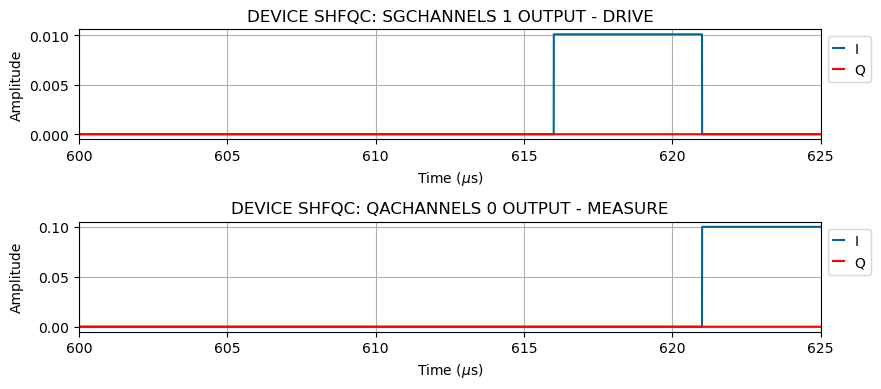

In [108]:
plot_simulation(compiled_rabi, start_time=600e-6, length=25e-6)

In [104]:
# run the compiled experiemnt
rabi_results = session.run()
timestamp = time.strftime("%Y%m%dT%H%M%S")
Path("Results").mkdir(parents=True, exist_ok=True)

[2025.08.24 19:38:12.567] INFO    Connecting to data server at 127.0.0.1:8004
[2025.08.24 19:38:12.570] INFO    Connected to Zurich Instruments LabOne Data Server version 25.04.0.628 at 127.0.0.1:8004
[2025.08.24 19:38:12.574] INFO    Configuring the device setup
[2025.08.24 19:38:12.581] INFO    The device setup is configured
[2025.08.24 19:38:12.889] INFO    Starting near-time execution...
[2025.08.24 19:38:16.946] INFO    Finished near-time execution.


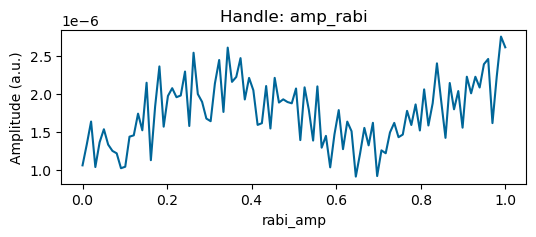

In [105]:
plot_results(rabi_results)

Fitted parameters: [   9.91561568   -0.25783174   -2.19807804 -102.36356517]


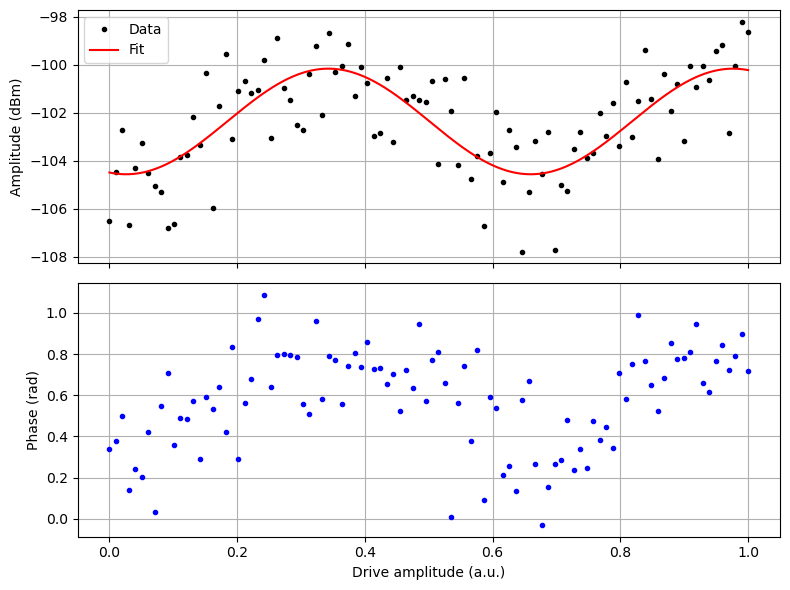

In [107]:
# --- Convert to dBm ---
def to_dbm(signal):
    power_W = (signal**2) / 50
    return 10 * np.log10(np.maximum(power_W, 1e-20) / 1e-3)  # avoid log(0)

# get measurement data returned by the instruments
rabi_res = rabi_results.get_data("amp_rabi")  # complex data
rabi_amp = rabi_results.get_axis("amp_rabi")[0]

# --- Compute quantities ---
amp_abs = np.abs(rabi_res)
amp_dbm = to_dbm(amp_abs)

phase_rad = np.arctan2(rabi_res.imag, rabi_res.real)

# --- Plot amplitude (dBm) ---
fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].plot(rabi_amp, amp_dbm, ".k", label="Data")
axs[0].set_ylabel("Amplitude (dBm)")
axs[0].grid(True)

# --- Fit amplitude data ---
amp_plot = np.linspace(rabi_amp[0], rabi_amp[-1], 5 * len(rabi_amp))
popt, pcov = oscillatory.fit(rabi_amp, amp_dbm, 10, 0, 1, 1.2, plot=False)
print(f"Fitted parameters: {popt}")

axs[0].plot(amp_plot, oscillatory(amp_plot, *popt), "-r", label="Fit")
axs[0].legend()

# --- Plot phase ---
axs[1].plot(rabi_amp, phase_rad, ".b")
axs[1].set_xlabel("Drive amplitude (a.u.)")
axs[1].set_ylabel("Phase (rad)")
axs[1].grid(True)

plt.tight_layout()
plt.show()